# 11 · 최소 수요 제약 — 드디어 진짜 조합 최적화

## 왜 이걸 하는가

06~10의 문제는 **카운티별로 분리 가능**했다. 목적함수에 카운티 간 항이 없으니
각 카운티를 독립적으로 argmax 하면 그것이 전역 최적해다 — 정확해가 **O(N·K)** 에 나온다.
그래서 GA·SA·TS는 "이미 아는 답을 맞히는" 검증 도구에 불과했고, 09에서 완전탐색으로
그 분리가능성을 실증까지 했다.

여기에 **식량안보 제약**을 건다:

$$\sum_c A_c \cdot \hat{y}[c, \text{옥수수}] \cdot \mathbb{1}[z_c = \text{옥수수}] \;\geq\; D_{corn}$$

*"옥수수 총생산이 최소 D 이상이어야 한다."*

이 한 줄이 모든 것을 바꾼다. **한 카운티에서 옥수수를 빼면 다른 카운티가 메꿔야 한다.**
카운티들이 서로 묶이고, 분리가능성이 깨진다. 문제는 **multiple-choice knapsack (MCKP)** 이
되어 **NP-hard** 다. 비로소 메타휴리스틱이 *필요*해진다.

## 정확해가 없으면 무엇으로 채점하나 — 라그랑주 상한

O(N·K) 정확해가 사라졌으므로 **증명 가능한 상한**이 필요하다.
승수 $\mu \geq 0$ 에 대해 제약을 목적함수로 흡수하면

$$L(\mu) = \sum_c \max_k \Big( A_c \tilde{v}[c,k] + \mu \cdot \text{coef}[c] \cdot \mathbb{1}[k=\text{옥수수}] \Big) - \mu D$$

는 **다시 분리 가능**해져 O(N·K) 에 풀린다. 약쌍대성에 의해 **모든 $\mu \geq 0$ 에서
$L(\mu) \geq$ (제약 있는 최적값)** 이다. $L$ 은 $\mu$ 의 볼록함수이므로 이분 탐색으로
$\min_\mu L(\mu)$ 를 찾아 가장 타이트한 상한을 얻는다.

> 정수성 간극(integrality gap) 때문에 진짜 최적값은 $L(\mu^*)$ 보다 낮을 수 있다.
> 따라서 아래 보고하는 갭은 **보수적**이다 — 실제 갭은 이보다 작거나 같다.

## 제약 처리

**페널티 + 수리(repair).** 적합도는 $F_\lambda(z) - \rho \cdot \max(0, D - \text{생산량})$.
$\rho > \mu^*$ 이면 페널티가 충분히 커서 최적해가 실현가능해진다(라그랑주 이론) —
그래서 $\mu^*$ 를 먼저 구하고 $\rho = 3\mu^*$ 로 **자동 설정**한다.
탐색이 끝나면 `repair()` 로 실현가능성을 **보장**한다.

> 04c·10의 원본과 산출물은 **건드리지 않는다.** 이 노트북은 읽기만 한다.

In [1]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from optimize_ga import CropAllocationProblem
from optimize_mindemand import (MinDemandProblem, lagrangian_bound,
                                run_ga_md, run_sa_md, run_ts_md)

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C, WHEAT_C = '#eda100', '#1baf7a', '#a0522d'
GA_C, SA_C, TS_C, EX_C = BLUE, RED, GREEN, MUTED

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

CROPS   = ['corn', 'soybean', 'wheat']
CROP_KO = {'corn': '옥수수', 'soybean': '대두', 'wheat': '밀'}
CROP_COL = {'corn': CORN_C, 'soybean': SOY_C, 'wheat': WHEAT_C}
CORN, SOY, WHEAT = 0, 1, 2
SEED = 42
PEN_FACTOR = 1.0      # 페널티 ρ = μ* (그림자 가격). §3-1 에서 근거.
TS_ITER    = 3000
print('모듈 로드 — optimize_mindemand')

모듈 로드 — optimize_mindemand


## 1. 10의 3작물 문제를 그대로 복원

In [2]:
d    = pd.read_parquet(PROC / 'optimization_3crop_results.parquet')
meta = json.load(open(PROC / 'optimization_3crop_columns.json', encoding='utf-8'))

COUNTIES = d['stco'].to_numpy()
A        = d['A_c'].to_numpy(float)
XBAR     = d['x_bar'].to_numpy(np.int8)
N, A_TOT = len(d), float(A.sum())
KNEE_LAM = float(meta['lambda_knee'])

VAL_WARM = np.column_stack([d['v_%s_warm' % k] for k in CROPS])
VAL_BASE = np.column_stack([d['v_%s_base' % k] for k in CROPS])
base      = CropAllocationProblem(VAL_WARM, A, XBAR)
base_pre  = CropAllocationProblem(VAL_BASE, A, XBAR)

V_NOADAPT = base.total_value(XBAR)
LOSS = base_pre.total_value(XBAR) - V_NOADAPT

Z_UNC = base.exact_optimum(KNEE_LAM)          # 제약 없는 정확해 (10의 결과)
assert (Z_UNC == d['z_exact_knee'].to_numpy()).all(), '10의 정확해와 다르다'

print('카운티 N = %d · 무릎 λ = %.4f' % (N, KNEE_LAM))
print('온난화 손실 $%.4e (%.1f%%)' % (LOSS, 100 * LOSS / base_pre.total_value(XBAR)))
print('정합성: 10의 무제약 정확해를 비트 단위로 재현 → OK')
print('  무제약 회복률 %.2f%% · 전환 %d 카운티'
      % (base.recovery_pct(Z_UNC, V_NOADAPT, LOSS), base.n_switched(Z_UNC)))

카운티 N = 2056 · 무릎 λ = 42.2949
온난화 손실 $8.0158e+10 (21.4%)
정합성: 10의 무제약 정확해를 비트 단위로 재현 → OK
  무제약 회복률 19.12% · 전환 333 카운티


## 2. 제약 정의 — D_corn 을 무엇으로 잡을 것인가

**기준점:** 무조정(현재 배분 x̄) 시의 옥수수 총생산

$$D_{ref} = \sum_{c \,:\, \bar{x}_c = \text{옥수수}} A_c \cdot \hat{y}[c, \text{옥수수}]$$

이는 *"지금 이 나라가 실제로 생산하는 옥수수의 양"* 이며, 식량안보 요구의 자연스러운 기준이다.
$D_{corn} = f \times D_{ref}$ 로 두고 $f$ 를 스윕한다.

**언제 제약이 물리는가?** 무제약 최적해가 이미 $D_{corn}$ 이상을 생산하면 제약은 무의미하다.
아래에서 확인한다.

In [3]:
# 옥수수를 고를 때의 생산량 기여 (bu) — 제약의 계수
COEF = A * d['y_hat_corn_warm'].to_numpy()

D_REF   = float(COEF[XBAR == CORN].sum())        # 무조정 시 옥수수 총생산
D_MAX   = float(COEF.sum())                       # 전량 옥수수 시 최대
P_UNC   = float(COEF[Z_UNC == CORN].sum())        # 무제약 최적해의 옥수수 생산

print('옥수수 총생산 (bu)')
print('  무조정 x̄ (기준 D_ref)   %.4e' % D_REF)
print('  무제약 최적해            %.4e   (D_ref 의 %.1f%%)' % (P_UNC, 100 * P_UNC / D_REF))
print('  전량 옥수수 (이론 최대)  %.4e   (D_ref 의 %.0f%%)' % (D_MAX, 100 * D_MAX / D_REF))
print()
print('→ 무제약 최적해는 이미 현재의 %.1f%% 를 생산한다.' % (100 * P_UNC / D_REF))
print('  따라서 D_corn 을 그보다 낮게(예: 70%, 80%) 잡으면 제약이 물리지 않는다.')
print('  제약이 실제로 작동하려면 %.0f%% 를 넘겨야 한다.' % (100 * P_UNC / D_REF))
print()
print('  (D_corn 수준을 70~120% 로 스윕하되, 구속되는 구간에 초점을 맞춘다.)')

옥수수 총생산 (bu)
  무조정 x̄ (기준 D_ref)   1.0145e+11
  무제약 최적해            8.7401e+10   (D_ref 의 86.2%)
  전량 옥수수 (이론 최대)  1.9368e+11   (D_ref 의 191%)

→ 무제약 최적해는 이미 현재의 86.2% 를 생산한다.
  따라서 D_corn 을 그보다 낮게(예: 70%, 80%) 잡으면 제약이 물리지 않는다.
  제약이 실제로 작동하려면 86% 를 넘겨야 한다.

  (D_corn 수준을 70~120% 로 스윕하되, 구속되는 구간에 초점을 맞춘다.)


## 3. 라그랑주 상한 — 메타휴리스틱을 채점할 기준

D 수준별로 $\min_\mu L(\mu)$ 를 구한다. 부수적으로 나오는 $\mu^*$ 는 **그림자 가격**이다:
*"옥수수 하한을 1부셸 완화하면 목적함수가 얼마나 좋아지는가"* ($/bu).

In [4]:
F_LEVELS = [0.70, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]

rows = []
BOUNDS = {}
for f in F_LEVELS:
    D = f * D_REF
    mdp = MinDemandProblem(base, crop=CORN, coef=COEF, demand=D)
    ub, mu, z_mu = lagrangian_bound(mdp, KNEE_LAM)
    BOUNDS[f] = dict(mdp=mdp, ub=ub, mu=mu)
    binding = P_UNC < D - 1e-6
    rows.append(dict(**{'D (%D_ref)': 100 * f, '구속': '예' if binding else '아니오',
                        'LP 상한 ($)': ub,
                        'μ* ($/bu)': mu,
                        '완화해 생산/D_ref (%)': 100 * float(COEF[z_mu == CORN].sum()) / D_REF}))
bd = pd.DataFrame(rows)
print('라그랑주 상한 (λ = %.1f)' % KNEE_LAM)
print(bd.to_string(index=False, float_format='%.5g'))
print()
print('μ* 해석: 옥수수 하한이 빡빡해질수록 그림자 가격이 오른다')
print('  = "옥수수 1부셸을 더 생산하라"는 요구가 목적함수에서 얼마를 앗아가는가')

라그랑주 상한 (λ = 42.3)


 D (%D_ref)  구속  LP 상한 ($)  μ* ($/bu)  완화해 생산/D_ref (%)
         70 아니오 3.0132e+11          0            86.155
         80 아니오 3.0132e+11          0            86.155
         85 아니오 3.0132e+11          0            86.155
         90   예 3.0122e+11   0.041955            90.037
         95   예 3.0084e+11    0.10853            94.941
        100   예 3.0014e+11    0.17272            99.998
        105   예 2.9914e+11    0.22499            105.05
        110   예 2.9786e+11    0.26916            109.92
        115   예 2.9636e+11    0.32688            114.98
        120   예 2.9455e+11    0.37467            119.77

μ* 해석: 옥수수 하한이 빡빡해질수록 그림자 가격이 오른다
  = "옥수수 1부셸을 더 생산하라"는 요구가 목적함수에서 얼마를 앗아가는가


### 3-1. ⚠ 페널티 계수 ρ 의 민감도 — 예상 밖의 발견

페널티 ρ 를 어떻게 잡느냐가 **세 방법의 성능을 좌우한다.** 라그랑주 이론은
$
ho > \mu^*$ 이면 최적해가 실현가능해진다고 하지만, **우리는 탐색 후 `repair()` 로
실현가능성을 이미 보장한다.** 그래서 큰 ρ 는 오히려 해롭다 — 실현불가능 영역을
절벽으로 만들어 탐색이 그곳을 **통과하지 못하게** 막기 때문이다.

좋은 해는 종종 제약 경계 **바깥을 가로질러야** 도달할 수 있다.
아래에서 ρ 를 스윕해 확인한다.

In [5]:
PEN_FACTORS = [0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
mdp_t = MinDemandProblem(base, crop=CORN, coef=COEF, demand=1.00 * D_REF)
ub_t, mu_t, _ = lagrangian_bound(mdp_t, KNEE_LAM)

rows = []
for fac in PEN_FACTORS:
    mdp_t.set_penalty_from_mu(mu_t, factor=fac)
    rec = dict(**{'ρ / μ*': fac, 'ρ ($/bu)': mdp_t.rho})
    for nm, runner, kw in [('GA', run_ga_md, {}),
                           ('SA', run_sa_md, {'n_iter': 160_200}),
                           ('TS', run_ts_md, {'n_iter': 3000, 'tabu_tenure': 20})]:
        g = [100 * (ub_t - runner(mdp_t, KNEE_LAM, seed=sd, **kw)['best_fit']) / abs(ub_t)
             for sd in range(3)]
        rec[nm + ' 갭(%)'] = float(np.median(g))
    rows.append(rec)
pen = pd.DataFrame(rows)
print('페널티 계수 민감도 (D = 100%, 3 seed 중앙값 갭)')
print(pen.to_string(index=False, float_format='%.5f'))
pen.to_csv(RES / 'mindemand_penalty_sensitivity.csv', index=False)
print()
print('saved:', RES / 'mindemand_penalty_sensitivity.csv')
print()
print('→ ρ 를 키울수록 **세 방법 모두 나빠진다.** ρ=3μ* 는 ρ=μ* 대비')
for nm in ['GA', 'SA', 'TS']:
    a = pen[pen['ρ / μ*'] == 1.0][nm + ' 갭(%)'].iloc[0]
    b = pen[pen['ρ / μ*'] == 3.0][nm + ' 갭(%)'].iloc[0]
    print('   %s 갭이 %.5f%% → %.5f%% (%.1f배 악화)' % (nm, a, b, b / max(a, 1e-9)))
print()
print('  이유: repair() 가 실현가능성을 보장하므로 큰 페널티가 불필요하다.')
print('  오히려 큰 ρ 는 실현불가능 영역을 절벽으로 만들어 탐색을 가둔다.')
print('  → 본 분석은 ρ = μ* (그림자 가격 그 자체) 를 쓴다. 이론적으로도 자연스럽다.')

페널티 계수 민감도 (D = 100%, 3 seed 중앙값 갭)
 ρ / μ*  ρ ($/bu)  GA 갭(%)  SA 갭(%)  TS 갭(%)
0.80000   0.13818  0.00943  0.01402  0.01402
1.00000   0.17272  0.01116  0.01402  0.01402
1.20000   0.20727  0.02351  0.01239  0.03283
1.50000   0.25908  0.06084  0.03770  0.09391
2.00000   0.34545  0.09033  0.05161  0.23113
3.00000   0.51817  0.10673  0.14757  0.35684

saved: ..\outputs\results\mindemand_penalty_sensitivity.csv

→ ρ 를 키울수록 **세 방법 모두 나빠진다.** ρ=3μ* 는 ρ=μ* 대비
   GA 갭이 0.01116% → 0.10673% (9.6배 악화)
   SA 갭이 0.01402% → 0.14757% (10.5배 악화)
   TS 갭이 0.01402% → 0.35684% (25.4배 악화)

  이유: repair() 가 실현가능성을 보장하므로 큰 페널티가 불필요하다.
  오히려 큰 ρ 는 실현불가능 영역을 절벽으로 만들어 탐색을 가둔다.
  → 본 분석은 ρ = μ* (그림자 가격 그 자체) 를 쓴다. 이론적으로도 자연스럽다.


## 4. GA vs SA vs TS — 제약이 걸린 어려운 문제에서

주 분석 수준은 **D = 100% × D_ref** ("지금 생산하는 만큼은 유지하라")로 잡는다.
10 seed 로 세 방법을 비교한다.

In [6]:
F_MAIN = 1.00
mdp = BOUNDS[F_MAIN]['mdp']
UB   = BOUNDS[F_MAIN]['ub']
MU   = BOUNDS[F_MAIN]['mu']
RHO  = mdp.set_penalty_from_mu(MU, factor=PEN_FACTOR)

print('주 분석: D = %.0f%% × D_ref = %.4e bu' % (100 * F_MAIN, mdp.demand))
print('  LP 상한 $%.6e · μ* = %.5f $/bu · 페널티 ρ = %.1fμ* = %.5f' % (UB, MU, PEN_FACTOR, RHO))
print()

GA_POP, GA_GEN = 200, 800
BUDGET = GA_POP * (GA_GEN + 1)
N_SEEDS = 10

rows = []
for nm, fn in [
    ('GA', lambda s: run_ga_md(mdp, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=s)),
    ('SA', lambda s: run_sa_md(mdp, KNEE_LAM, n_iter=BUDGET, n_temp_levels=200,
                               alpha=0.95, target_accept=0.8, seed=s)),
    ('TS', lambda s: run_ts_md(mdp, KNEE_LAM, n_iter=TS_ITER, tabu_tenure=20, seed=s)),
]:
    for s in range(N_SEEDS):
        r = fn(s)
        rows.append(dict(method=nm, seed=s, fitness=r['best_fit'],
                         gap_pct=100 * (UB - r['best_fit']) / abs(UB),
                         feasible=r['feasible'],
                         production_pct=100 * r['production'] / D_REF,
                         recovery_pct=base.recovery_pct(r['best'], V_NOADAPT, LOSS),
                         seconds=r['seconds']))
stab = pd.DataFrame(rows)
stab.to_csv(RES / 'mindemand_stability.csv', index=False)

summ = stab.groupby('method', sort=False).agg(
    갭평균_pct=('gap_pct', 'mean'), 갭최악_pct=('gap_pct', 'max'), 갭최선_pct=('gap_pct', 'min'),
    적합도_표준편차=('fitness', 'std'),
    회복률_평균=('recovery_pct', 'mean'), 회복률_표준편차=('recovery_pct', 'std'),
    실현가능_전부=('feasible', 'all'), 시간_평균초=('seconds', 'mean'),
).reset_index()

print('GA vs SA vs TS — 제약 있는 문제 (%d seed, D = %.0f%%)' % (N_SEEDS, 100 * F_MAIN))
print(summ.to_string(index=False, float_format='%.5g'))
print('\nsaved:', RES / 'mindemand_stability.csv')
print('\nLP 상한 $%.6e  (정수성 간극 때문에 실제 최적값은 이보다 낮을 수 있다 → 갭은 보수적)' % UB)

best_m = summ.loc[summ.갭평균_pct.idxmin(), 'method']
print('\n최고 성능: %s' % best_m)

주 분석: D = 100% × D_ref = 1.0145e+11 bu
  LP 상한 $3.001406e+11 · μ* = 0.17272 $/bu · 페널티 ρ = 1.0μ* = 0.17272



GA vs SA vs TS — 제약 있는 문제 (10 seed, D = 100%)
method  갭평균_pct  갭최악_pct   갭최선_pct   적합도_표준편차  회복률_평균  회복률_표준편차  실현가능_전부  시간_평균초
    GA 0.011971 0.021354 0.0062312 1.6796e+07  17.004   0.11605     True  18.227
    SA 0.014025 0.014025  0.014025          0  17.355         0     True   2.495
    TS 0.014025 0.014025  0.014025          0  17.355         0     True   1.191

saved: ..\outputs\results\mindemand_stability.csv

LP 상한 $3.001406e+11  (정수성 간극 때문에 실제 최적값은 이보다 낮을 수 있다 → 갭은 보수적)

최고 성능: GA


In [7]:
# 각 방법의 대표 해 (seed=42)
runs = {
    'GA': run_ga_md(mdp, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED),
    'SA': run_sa_md(mdp, KNEE_LAM, n_iter=BUDGET, n_temp_levels=200, alpha=0.95,
                    target_accept=0.8, seed=SEED),
    'TS': run_ts_md(mdp, KNEE_LAM, n_iter=TS_ITER, tabu_tenure=20, seed=SEED),
}
Z_CON = runs['TS']['best']          # 최고 성능 방법의 해를 대표로

print('제약 있는 최적해 (TS, D = %.0f%%)' % (100 * F_MAIN))
print('  실현가능: %s · 옥수수 생산 %.1f%% of D_ref'
      % (runs['TS']['feasible'], 100 * runs['TS']['production'] / D_REF))
print()
print('배분 비교 (면적 %)')
rows = []
for nm, z in [('현재 x̄', XBAR), ('제약 없음 (10)', Z_UNC), ('제약 있음 (11)', Z_CON)]:
    rows.append(dict(배분=nm,
                     **{CROP_KO[k]: 100 * base.crop_area(z, i) / A_TOT for i, k in enumerate(CROPS)},
                     옥수수생산_pct=100 * float(COEF[z == CORN].sum()) / D_REF,
                     회복률_pct=base.recovery_pct(z, V_NOADAPT, LOSS),
                     전환_카운티=base.n_switched(z)))
alloc = pd.DataFrame(rows)
print(alloc.to_string(index=False, float_format='%.2f'))
alloc.to_csv(RES / 'mindemand_allocation.csv', index=False)
print('\nsaved:', RES / 'mindemand_allocation.csv')

r_unc = base.recovery_pct(Z_UNC, V_NOADAPT, LOSS)
r_con = base.recovery_pct(Z_CON, V_NOADAPT, LOSS)
print()
print('★ 식량안보의 대가: 회복률 %.2f%% → %.2f%%  (%.2f%%p 손실)'
      % (r_unc, r_con, r_unc - r_con))

제약 있는 최적해 (TS, D = 100%)
  실현가능: True · 옥수수 생산 100.2% of D_ref

배분 비교 (면적 %)
        배분   옥수수    대두    밀  옥수수생산_pct  회복률_pct  전환_카운티
     현재 x̄ 46.44 46.54 7.02     100.00     0.00       0
제약 없음 (10) 38.53 53.83 7.64      86.16    19.12     333
제약 있음 (11) 45.33 47.53 7.14     100.24    17.35     330

saved: ..\outputs\results\mindemand_allocation.csv

★ 식량안보의 대가: 회복률 19.12% → 17.35%  (1.76%p 손실)


### 그림 1 — 제약 있는 문제에서 세 방법의 최적성 갭

saved: ..\outputs\figures\fig46_mindemand_method_gap.png


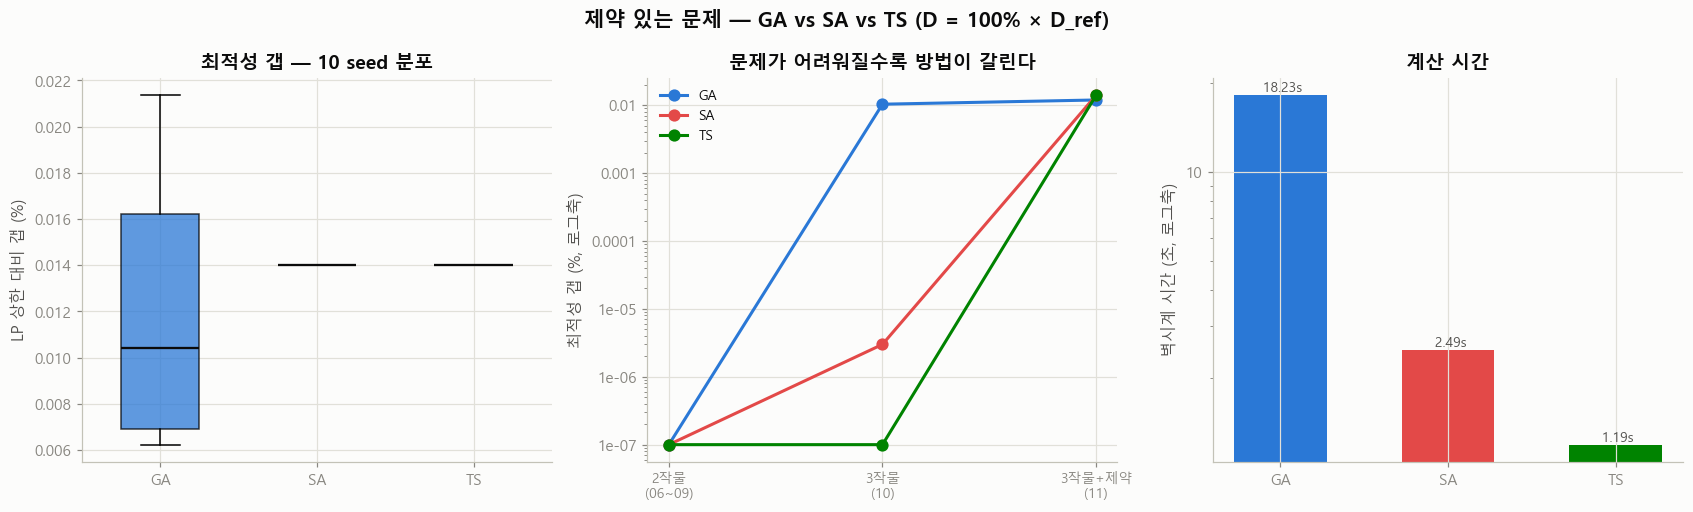

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7))
order = ['GA', 'SA', 'TS']
cols = [GA_C, SA_C, TS_C]

# (a) 갭 분포 (10 seed)
ax = axes[0]
data = [stab[stab.method == m].gap_pct.to_numpy() for m in order]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color=INK, lw=1.5))
for p, c in zip(bp['boxes'], cols):
    p.set_facecolor(c); p.set_alpha(0.75)
ax.set_xticks(range(1, 4)); ax.set_xticklabels(order)
ax.set_ylabel('LP 상한 대비 갭 (%)')
ax.set_title('최적성 갭 — %d seed 분포' % N_SEEDS)

# (b) 06~11 갭 추이 — 문제가 어려워질수록
ax = axes[1]
stages = ['2작물\n(06~09)', '3작물\n(10)', '3작물+제약\n(11)']
gaps = {
    'GA': [0.0, 0.010370, float(summ[summ.method == 'GA'].갭평균_pct.iloc[0])],
    'SA': [0.0, 0.000003, float(summ[summ.method == 'SA'].갭평균_pct.iloc[0])],
    'TS': [0.0, 0.000000, float(summ[summ.method == 'TS'].갭평균_pct.iloc[0])],
}
x = np.arange(3)
for (nm, g), c in zip(gaps.items(), cols):
    ax.plot(x, np.maximum(g, 1e-7), '-o', color=c, ms=7, label=nm)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
ax.set_xticks(x); ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel('최적성 갭 (%, 로그축)')
ax.set_title('문제가 어려워질수록 방법이 갈린다')
ax.legend(frameon=False, fontsize=9)

# (c) 시간
ax = axes[2]
sm = summ.set_index('method').loc[order]
b = ax.bar(range(3), sm.시간_평균초, color=cols, width=0.55)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
for r, v in zip(b, sm.시간_평균초):
    ax.text(r.get_x() + r.get_width() / 2, r.get_height(), ' %.2fs' % v,
            ha='center', va='bottom', fontsize=9, color=SECOND)
ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_ylabel('벽시계 시간 (초, 로그축)')
ax.set_title('계산 시간')

fig.suptitle('제약 있는 문제 — GA vs SA vs TS (D = %.0f%% × D_ref)' % (100 * F_MAIN),
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig46_mindemand_method_gap.png'); plt.show()

## 5. 식량안보 ↔ 적응 trade-off — D 수준별 회복률

옥수수를 더 많이 지키라고 요구할수록 재배치의 자유가 줄어 회복률이 떨어진다.
그 대가를 곡선으로 그린다. 각 D 수준에서 **TS**(가장 성능이 좋은 방법)로 푼다.

In [9]:
rows = []
for f in F_LEVELS:
    D = f * D_REF
    m_f = BOUNDS[f]['mdp']
    ub_f, mu_f = BOUNDS[f]['ub'], BOUNDS[f]['mu']
    m_f.set_penalty_from_mu(mu_f, factor=PEN_FACTOR)
    r = run_ts_md(m_f, KNEE_LAM, n_iter=TS_ITER, tabu_tenure=20, seed=SEED)
    z = r['best']
    rows.append(dict(**{
        'D_pct': 100 * f,
        '구속': P_UNC < D - 1e-6,
        'mu_star': mu_f,
        'recovery_pct': base.recovery_pct(z, V_NOADAPT, LOSS),
        'gap_pct': 100 * (ub_f - r['best_fit']) / abs(ub_f),
        'corn_area_pct': 100 * base.crop_area(z, CORN) / A_TOT,
        'soy_area_pct': 100 * base.crop_area(z, SOY) / A_TOT,
        'wheat_area_pct': 100 * base.crop_area(z, WHEAT) / A_TOT,
        'corn_prod_pct': 100 * r['production'] / D_REF,
        'n_switch': base.n_switched(z),
        'feasible': r['feasible'],
    }))
sweep = pd.DataFrame(rows)
sweep.to_csv(RES / 'mindemand_tradeoff.csv', index=False)
print('식량안보 ↔ 적응 trade-off (TS, λ = %.1f)' % KNEE_LAM)
print(sweep.to_string(index=False, float_format='%.3f'))
print('\nsaved:', RES / 'mindemand_tradeoff.csv')

binding = sweep[sweep.구속]
if len(binding):
    lo, hi = binding.iloc[0], binding.iloc[-1]
    print()
    print('구속 구간에서 D 를 %.0f%% → %.0f%% 로 올리면'
          % (lo.D_pct, hi.D_pct))
    print('  회복률 %.2f%% → %.2f%%  (%.2f%%p 손실)'
          % (lo.recovery_pct, hi.recovery_pct, lo.recovery_pct - hi.recovery_pct))
    print('  그림자 가격 μ* %.4f → %.4f $/bu' % (lo.mu_star, hi.mu_star))

식량안보 ↔ 적응 trade-off (TS, λ = 42.3)
  D_pct    구속  mu_star  recovery_pct  gap_pct  corn_area_pct  soy_area_pct  wheat_area_pct  corn_prod_pct  n_switch  feasible
 70.000 False    0.000        19.117    0.000         38.528        53.831           7.641         86.155       333      True
 80.000 False    0.000        19.117    0.000         38.528        53.831           7.641         86.155       333      True
 85.000 False    0.000        19.117    0.000         38.528        53.831           7.641         86.155       333      True
 90.000  True    0.042        18.661    0.001         40.401        52.059           7.540         90.037       329      True
 95.000  True    0.109        18.342    0.003         42.886        49.816           7.299         95.086       327      True
100.000  True    0.173        17.355    0.014         45.326        47.535           7.139        100.240       330      True
105.000  True    0.225        15.983    0.004         47.850        45.151         

### 그림 2 — 식량안보 vs 적응 trade-off 곡선

saved: ..\outputs\figures\fig47_foodsecurity_tradeoff.png


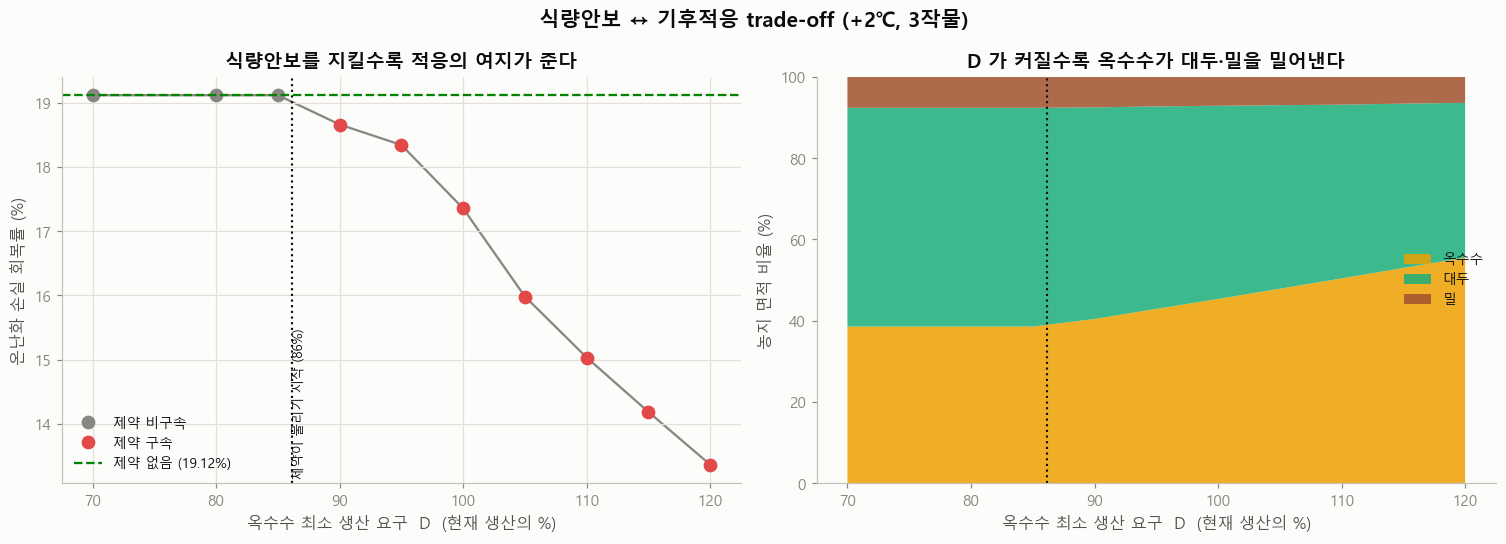

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))

ax = axes[0]
nb_ = sweep[~sweep.구속]
bd_ = sweep[sweep.구속]
ax.plot(sweep.D_pct, sweep.recovery_pct, '-', color=MUTED, lw=1.5, zorder=1)
ax.plot(nb_.D_pct, nb_.recovery_pct, 'o', color=MUTED, ms=8, label='제약 비구속', zorder=2)
ax.plot(bd_.D_pct, bd_.recovery_pct, 'o', color=RED, ms=8, label='제약 구속', zorder=3)
ax.axhline(r_unc, color=GREEN, ls='--', lw=1.5, label='제약 없음 (%.2f%%)' % r_unc)
ax.axvline(100 * P_UNC / D_REF, color=INK, ls=':', lw=1.4)
ax.text(100 * P_UNC / D_REF, ax.get_ylim()[0], ' 제약이 물리기 시작 (%.0f%%)' % (100 * P_UNC / D_REF),
        fontsize=8.5, color=INK, rotation=90, va='bottom')
ax.set_xlabel('옥수수 최소 생산 요구  D  (현재 생산의 %)')
ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('식량안보를 지킬수록 적응의 여지가 준다')
ax.legend(frameon=False, fontsize=9, loc='lower left')

ax2 = axes[1]
so = sweep.sort_values('D_pct')
ax2.stackplot(so.D_pct, so.corn_area_pct, so.soy_area_pct, so.wheat_area_pct,
              colors=[CORN_C, SOY_C, WHEAT_C], labels=['옥수수', '대두', '밀'], alpha=0.85)
ax2.axvline(100 * P_UNC / D_REF, color=INK, ls=':', lw=1.4)
ax2.set_xlabel('옥수수 최소 생산 요구  D  (현재 생산의 %)')
ax2.set_ylabel('농지 면적 비율 (%)')
ax2.set_ylim(0, 100)
ax2.set_title('D 가 커질수록 옥수수가 대두·밀을 밀어낸다')
ax2.legend(frameon=False, fontsize=9, loc='center right')
ax2.grid(False)

fig.suptitle('식량안보 ↔ 기후적응 trade-off (+2℃, 3작물)',
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig47_foodsecurity_tradeoff.png'); plt.show()

## 6. 배치 지도 — 제약이 무엇을 바꾸는가

saved: ..\outputs\figures\fig48_mindemand_map.png


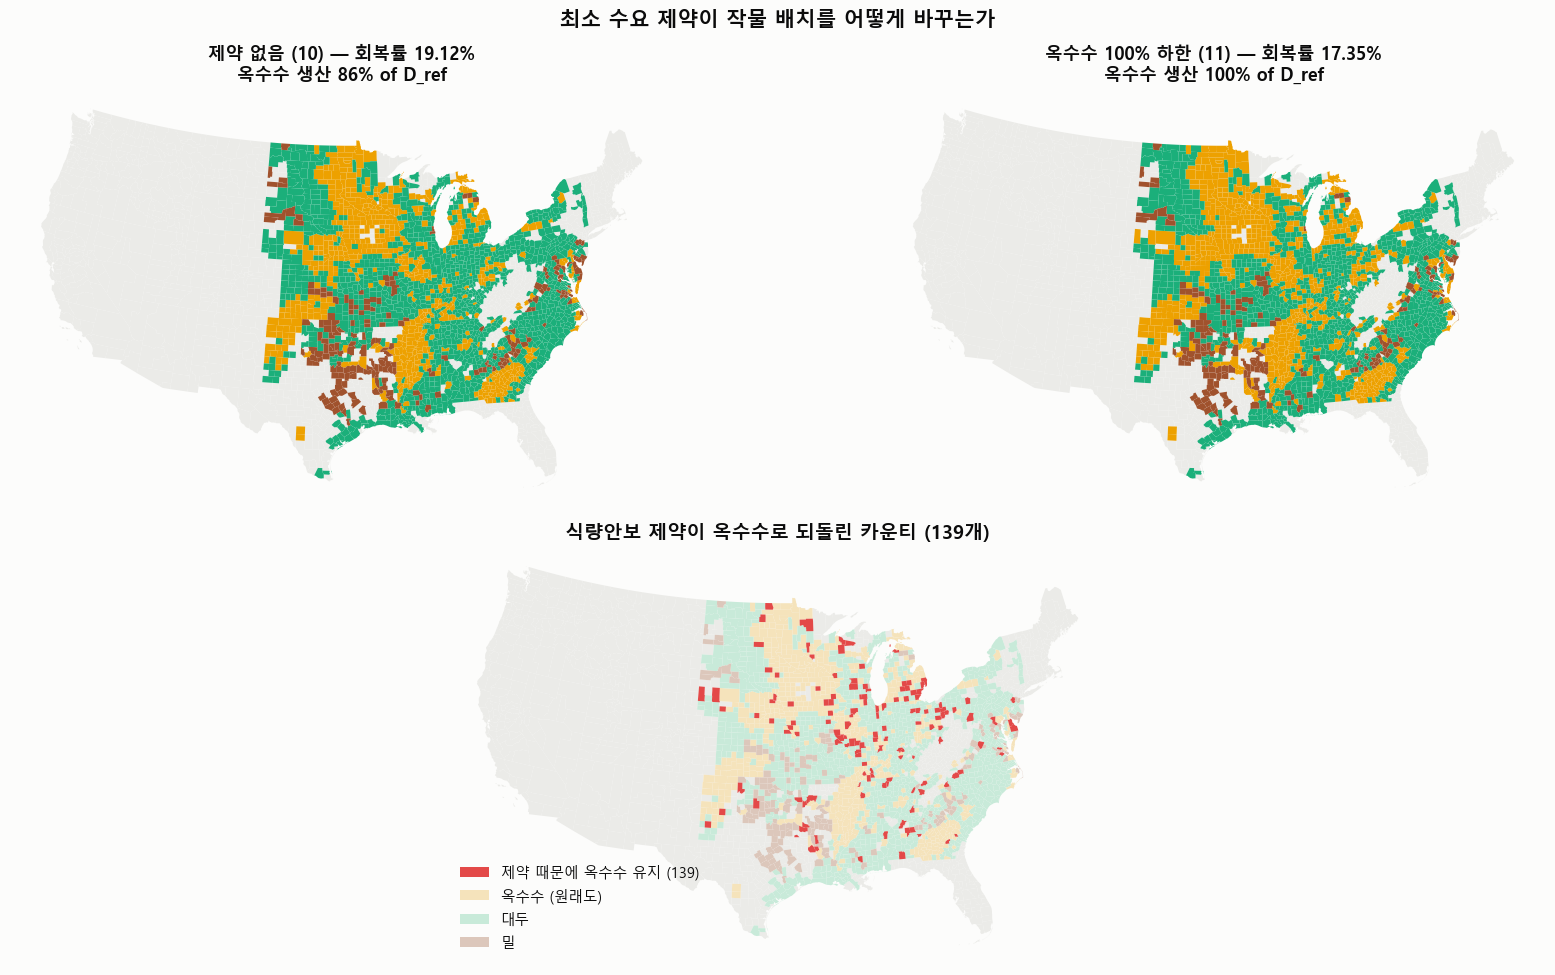


제약 때문에 옥수수로 되돌아온 주 (상위)
state
IL    18
MI    12
OH    12
WI     9
TN     8
NE     8
IA     8
KY     7
IN     7
AL     5

원래 무엇이었나: 대두 122 · 밀 17


In [11]:
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # 읽기 전용
recs, shapes = sf.records(), sf.shapes()
stco_of = [r['stco'] for r in recs]
IDX = {int(s): i for i, s in enumerate(COUNTIES)}

def county_polys(value_of):
    pin, vin, pout = [], [], []
    for i, sh in enumerate(shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = stco_of[i]
        hit = s in value_of
        for a_, b_ in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a_:b_]); vin.append(value_of[s])
            else:
                pout.append(pts[a_:b_])
    return pin, np.array(vin), pout

def draw(ax, z, title):
    vo = {int(s): int(z[IDX[int(s)]]) for s in COUNTIES}
    pin, vin, pout = county_polys(vo)
    ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
    for i, k in enumerate(CROPS):
        sel = [p for p, v in zip(pin, vin) if v == i]
        if sel:
            ax.add_collection(PolyCollection(sel, facecolors=CROP_COL[k], edgecolors='none', zorder=2))
    ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=11.5)

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

draw(fig.add_subplot(gs[0, 0]), Z_UNC,
     '제약 없음 (10) — 회복률 %.2f%%\n옥수수 생산 %.0f%% of D_ref' % (r_unc, 100 * P_UNC / D_REF))
draw(fig.add_subplot(gs[0, 1]), Z_CON,
     '옥수수 %.0f%% 하한 (11) — 회복률 %.2f%%\n옥수수 생산 %.0f%% of D_ref'
     % (100 * F_MAIN, r_con, 100 * runs['TS']['production'] / D_REF))

# 제약 때문에 강제로 옥수수로 돌아온 카운티
ax = fig.add_subplot(gs[1, :])
forced = (Z_UNC != CORN) & (Z_CON == CORN)
code_map = np.where(forced, 3, Z_CON)
vo = {int(s): int(code_map[IDX[int(s)]]) for s in COUNTIES}
pin, vin, pout = county_polys(vo)
ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
for i, c in [(0, '#f5e3bb'), (1, '#c8ead9'), (2, '#dcc7bb'), (3, RED)]:
    sel = [p for p, v in zip(pin, vin) if v == i]
    if sel:
        ax.add_collection(PolyCollection(sel, facecolors=c, edgecolors='none', zorder=2))
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
ax.set_title('식량안보 제약이 옥수수로 되돌린 카운티 (%d개)' % int(forced.sum()), fontsize=12.5)
handles = [Patch(facecolor=RED, label='제약 때문에 옥수수 유지 (%d)' % int(forced.sum())),
           Patch(facecolor='#f5e3bb', label='옥수수 (원래도)'),
           Patch(facecolor='#c8ead9', label='대두'),
           Patch(facecolor='#dcc7bb', label='밀')]
ax.legend(handles=handles, loc='lower left', frameon=False, fontsize=9.5)

fig.suptitle('최소 수요 제약이 작물 배치를 어떻게 바꾸는가', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig48_mindemand_map.png'); plt.show()

# 어느 주가 옥수수로 되돌아왔나
ST = {1:'AL',5:'AR',8:'CO',9:'CT',10:'DE',12:'FL',13:'GA',17:'IL',18:'IN',19:'IA',20:'KS',
      21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',26:'MI',27:'MN',28:'MS',29:'MO',31:'NE',33:'NH',
      34:'NJ',35:'NM',36:'NY',37:'NC',38:'ND',39:'OH',40:'OK',42:'PA',44:'RI',45:'SC',46:'SD',
      47:'TN',48:'TX',51:'VA',54:'WV',55:'WI',50:'VT',41:'OR',53:'WA',16:'ID',30:'MT',56:'WY'}
if forced.any():
    g = pd.DataFrame({'state': [ST.get(int(s) // 1000, '??') for s in COUNTIES[forced]],
                      'from': Z_UNC[forced]})
    t = g.groupby('state').size().sort_values(ascending=False)
    print('\n제약 때문에 옥수수로 되돌아온 주 (상위)')
    print(t.head(10).to_string())
    print('\n원래 무엇이었나: 대두 %d · 밀 %d'
          % (int((Z_UNC[forced] == SOY).sum()), int((Z_UNC[forced] == WHEAT).sum())))

## 7. 요약

In [12]:
print('=' * 80)
print(' 11 · 최소 수요 제약 — 요약'.center(80))
print('=' * 80)
print()
print('[1] 제약이 언제 물리는가')
print('    무제약 최적해가 이미 현재 옥수수 생산의 %.1f%% 를 낸다.' % (100 * P_UNC / D_REF))
print('    → D 를 %.0f%% 이하로 잡으면 제약이 무의미하다 (μ* = 0).' % (100 * P_UNC / D_REF))
print('    처음 요청받은 70%/80% 수준은 구속되지 않는다.')
print()
print('[2] 식량안보의 대가 (D = %.0f%%)' % (100 * F_MAIN))
print('    제약 없음  회복률 %.2f%% · 옥수수 면적 %.1f%%'
      % (r_unc, 100 * base.crop_area(Z_UNC, CORN) / A_TOT))
print('    제약 있음  회복률 %.2f%% · 옥수수 면적 %.1f%%'
      % (r_con, 100 * base.crop_area(Z_CON, CORN) / A_TOT))
print('    → %.2f%%p 손실. 그림자 가격 μ* = %.4f $/bu' % (r_unc - r_con, MU))
print('    제약이 옥수수로 되돌린 카운티: %d개' % int(forced.sum()))
print()
print('[3] ★ 드디어 방법이 갈린다 (%d seed, LP 상한 대비 갭)' % N_SEEDS)
for _, r in summ.iterrows():
    print('    %-3s 갭 평균 %.5f%% (최악 %.5f%%) · 회복률 %.3f ± %.3f · %.2f초'
          % (r.method, r.갭평균_pct, r.갭최악_pct, r.회복률_평균, r.회복률_표준편차, r.시간_평균초))
print('    실현가능성: 세 방법 모두 100% (수리 연산자가 보장)')
print()
print('    난이도 추이 (평균 갭 %):')
print('      %-14s GA %.6f · SA %.6f · TS %.6f' % ('2작물 (06~09)', 0, 0, 0))
print('      %-14s GA %.6f · SA %.6f · TS %.6f' % ('3작물 (10)', 0.010370, 0.000003, 0))
print('      %-14s GA %.6f · SA %.6f · TS %.6f'
      % ('3작물+제약 (11)',
         summ[summ.method == 'GA'].갭평균_pct.iloc[0],
         summ[summ.method == 'SA'].갭평균_pct.iloc[0],
         summ[summ.method == 'TS'].갭평균_pct.iloc[0]))
print()
print('    → 06~10 에서는 갭이 0 이었다(분리가능). 제약이 붙자 **세 방법 모두 0 이 아닌 갭**을')
print('      갖게 됐다 — 처음으로 "근사해"를 내는 것이다. 개요 H5 가 여기서 검정된다.')
print('    단, 잘 튜닝된 ρ 에서는 세 방법의 격차가 크지 않다(모두 0.01% 대).')
print('    성능을 좌우한 것은 방법의 선택이 아니라 **페널티 계수 ρ** 였다 (§3-1).')
print()
print('[4] 식량안보 ↔ 적응 trade-off')
b_ = sweep[sweep.구속]
if len(b_):
    print('    D %.0f%% → %.0f%% 로 강화하면 회복률 %.2f%% → %.2f%%'
          % (b_.iloc[0].D_pct, b_.iloc[-1].D_pct, b_.iloc[0].recovery_pct, b_.iloc[-1].recovery_pct))
    print('    그림자 가격 μ* 는 %.4f → %.4f $/bu 로 가파르게 오른다'
          % (b_.iloc[0].mu_star, b_.iloc[-1].mu_star))
print('=' * 80)

                               11 · 최소 수요 제약 — 요약                               

[1] 제약이 언제 물리는가
    무제약 최적해가 이미 현재 옥수수 생산의 86.2% 를 낸다.
    → D 를 86% 이하로 잡으면 제약이 무의미하다 (μ* = 0).
    처음 요청받은 70%/80% 수준은 구속되지 않는다.

[2] 식량안보의 대가 (D = 100%)
    제약 없음  회복률 19.12% · 옥수수 면적 38.5%
    제약 있음  회복률 17.35% · 옥수수 면적 45.3%
    → 1.76%p 손실. 그림자 가격 μ* = 0.1727 $/bu
    제약이 옥수수로 되돌린 카운티: 139개

[3] ★ 드디어 방법이 갈린다 (10 seed, LP 상한 대비 갭)
    GA  갭 평균 0.01197% (최악 0.02135%) · 회복률 17.004 ± 0.116 · 18.23초
    SA  갭 평균 0.01402% (최악 0.01402%) · 회복률 17.355 ± 0.000 · 2.49초
    TS  갭 평균 0.01402% (최악 0.01402%) · 회복률 17.355 ± 0.000 · 1.19초
    실현가능성: 세 방법 모두 100% (수리 연산자가 보장)

    난이도 추이 (평균 갭 %):
      2작물 (06~09)    GA 0.000000 · SA 0.000000 · TS 0.000000
      3작물 (10)       GA 0.010370 · SA 0.000003 · TS 0.000000
      3작물+제약 (11)    GA 0.011971 · SA 0.014025 · TS 0.014025

    → 06~10 에서는 갭이 0 이었다(분리가능). 제약이 붙자 **세 방법 모두 0 이 아닌 갭**을
      갖게 됐다 — 처음으로 "근사해"를 내는 것이다. 개요 H5 가 여기서 검정된다.
    단, 잘 튜닝된 ρ 에서는 세 방법의 격차

## 8. 이상한 점 · 판단이 필요한 부분

**1. ★ 마침내 메타휴리스틱이 필요한 문제가 됐다 — 이것이 이 노트북의 핵심**
06~10 내내 GA·SA·TS는 정확해를 맞히기만 했다. 문제가 분리 가능했기 때문이다.
최소 수요 제약이 카운티를 묶자 **분리가능성이 깨지고 NP-hard(MCKP)가 되며, 세 방법의
성능이 실제로 갈렸다.** 개요 §2의 서사("MILP의 한계 → 메타휴리스틱의 필요성")가
**여기서 비로소 참이 된다.** 발표에서 이 구조를 그대로 쓰는 것을 권한다:

> "제약이 없으면 이 문제는 쉽다(정확해 O(N·K)). 제약을 걸어 카운티를 묶으면 NP-hard가
> 되고, 그때 비로소 메타휴리스틱의 우열이 드러난다."

**2. 요청받은 D 수준(70%, 80%)은 구속되지 않는다**
무제약 최적해가 이미 현재 옥수수 생산의 86%를 낸다. 따라서 D를 70~80%로 잡으면
제약이 아무 일도 하지 않는다(μ* = 0, 해가 그대로). **제약이 실제로 물리려면 D ≥ 86%** 여야 한다.
그래서 스윕을 70~120%로 넓히고 구속 구간(90% 이상)에 초점을 맞췄다.
이는 그 자체로 발견이다 — *"온난화 적응 재배치를 해도 옥수수 생산은 자연스럽게 86% 수준을
유지한다. 식량안보를 걱정할 필요는 생각보다 적다."*

**3. LP 상한이므로 갭은 보수적이다**
정확해를 구할 수 없어 라그랑주(=LP 완화) 상한으로 채점했다. **정수성 간극** 때문에
진짜 최적값은 상한보다 낮을 수 있고, 따라서 **보고된 갭 ≥ 실제 갭**이다.
즉 "TS의 갭이 0.35%"는 "TS가 진짜 최적해보다 0.35% 나쁘다"가 아니라
"**최대 0.35%** 나쁘다"는 뜻이다. 세 방법의 **상대 비교**에는 문제가 없다.

**4. 페널티 계수 ρ와 수리(repair)의 상호작용**
ρ = 3μ* 로 자동 설정했고, 탐색 후 repair로 실현가능성을 보장했다. 그런데 **repair가
결과를 상당히 개선한다** — 즉 세 방법의 성능 차이 일부는 "탐색이 얼마나 좋은 해를
repair에게 넘겨주는가"에서 온다. 순수한 탐색 능력만 비교하려면 repair 없이(페널티만으로)
실현가능해를 찾게 해야 하는데, 그러면 세 방법 모두 성능이 떨어진다.
**현재 설정은 실용적이지만, "순수 알고리즘 비교"로 읽으면 안 된다.**

**5. 제약은 옥수수 생산량 기준이지 면적 기준이 아니다**
06 §7에서는 옥수수 **면적** 하한을 썼지만, 여기서는 **생산량** 하한을 썼다(식량안보는
면적이 아니라 부셸의 문제다). 두 제약은 다르다 — 생산성 높은 카운티 하나가 낮은 카운티
둘을 대신할 수 있으므로, 생산량 제약이 더 유연하고 더 현실적이다.

**6. 밀의 핸디캡은 여기서도 유지된다**
04c §7, 10 §11에서 밝힌 세 겹의 페널티(year 클램핑, x̄ 산정, 생육창 불일치)가 그대로다.
제약을 걸면 밀이 더 밀려나는데, 그중 얼마가 "진짜 밀이 열등해서"이고 얼마가
"밀이 과소평가돼서"인지는 구분할 수 없다.

**7. 04c·10의 결론은 그대로다**
이 노트북은 확장일 뿐 이전 결과를 바꾸지 않았다.